In [2]:
import numpy as np
import matplotlib.pyplot as plt
import modules.loaddata
import importlib

In [3]:
qvals, data = modules.loaddata.load_ab_initio("data/ab_initio_nu_responses/")

In [3]:
data[0][0]

array([[1.39840054e+01, 1.41090054e+01, 1.42340054e+01, ...,
        5.13734005e+02, 5.13859005e+02, 5.13984005e+02],
       [0.00000000e+00, 2.96748304e+00, 4.22519518e+00, ...,
        2.06443326e-03, 2.05818664e-03, 2.05195829e-03],
       [0.00000000e+00, 5.21346623e-02, 1.89955314e-01, ...,
        1.48479962e-05, 1.47685721e-05, 1.46895694e-05],
       [0.00000000e+00, 5.88283141e+00, 8.26043505e+00, ...,
        4.11401853e-03, 4.10160471e-03, 4.08922702e-03]], shape=(4, 4001))

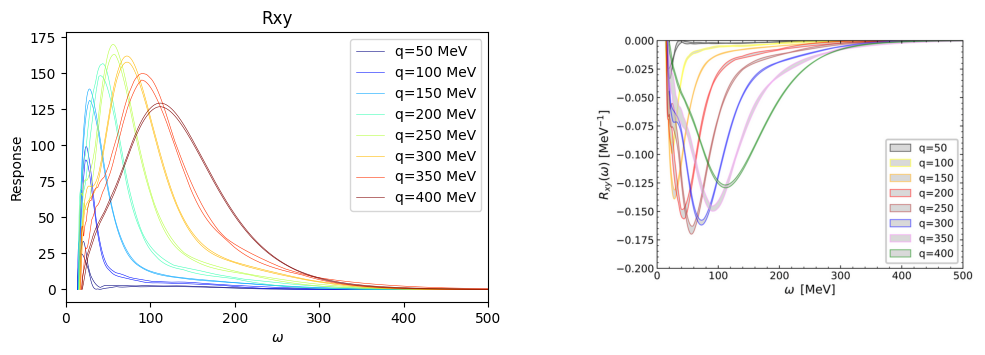

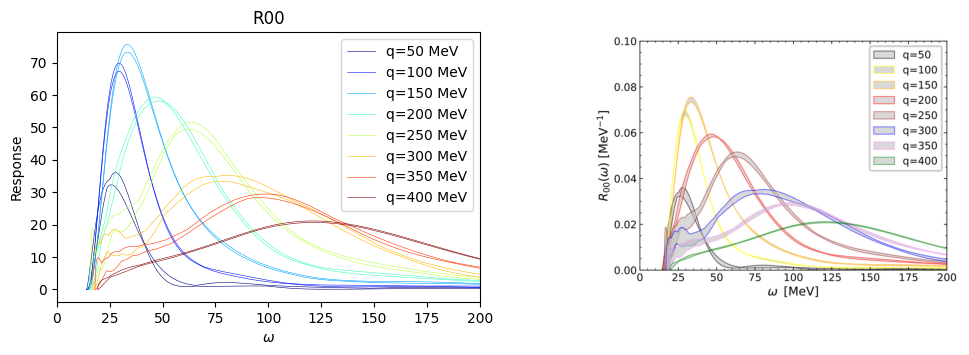

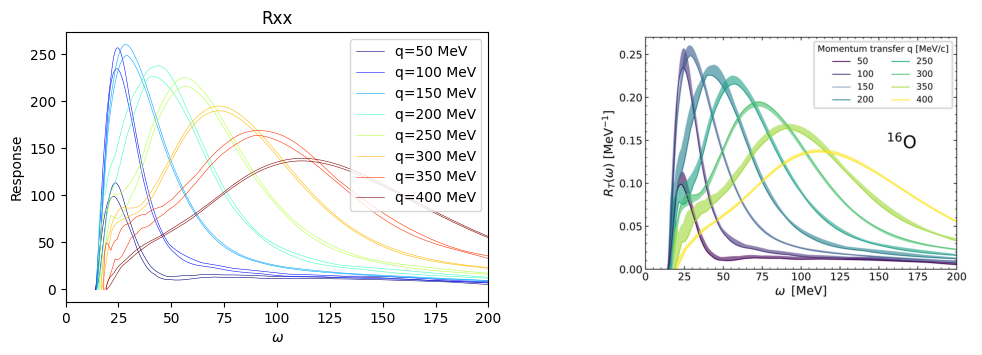

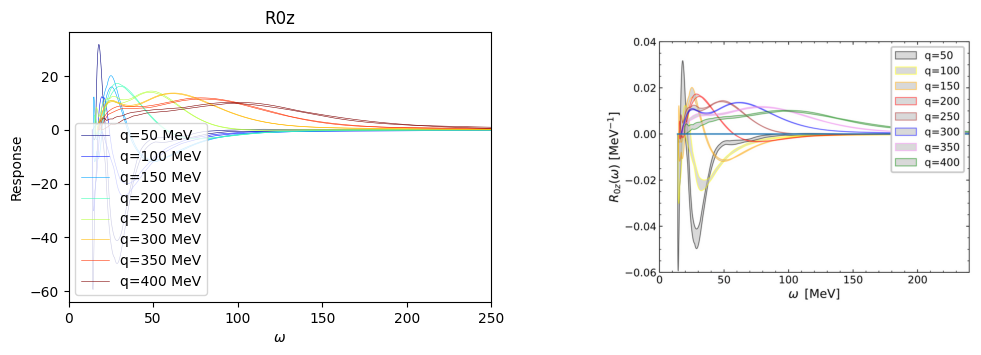

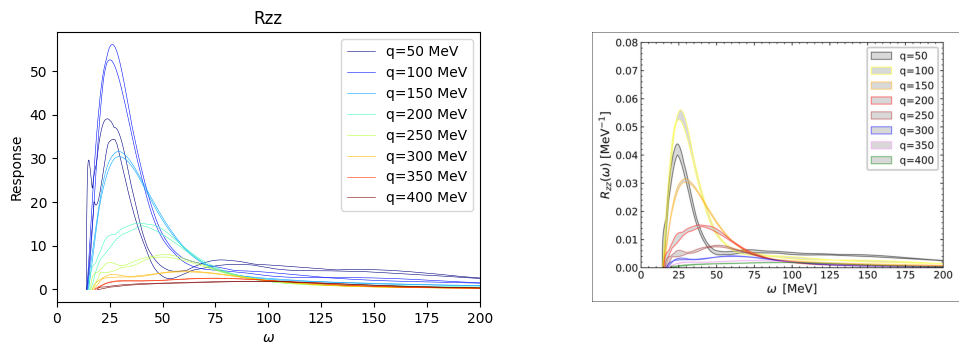

In [4]:
import modules.utils
c = modules.utils.generate_colourscale(len(qvals))
xlims = [500, 200, 200, 250, 200]
curvenames = modules.loaddata.ab_initio_curvenames
curvenames[2] = "Rxx"
for i, curve in enumerate(curvenames):
    fig, axs = plt.subplots(1,2, figsize=(12,3.5))
    if curve == "Rt":
        continue
    for qidx, q in enumerate(qvals):
        axs[0].plot(data[qidx][i][0], data[qidx][i][2], label=f"q={q} MeV", color=c[qidx], linewidth=0.4)
        axs[0].plot(data[qidx][i][0], data[qidx][i][3], color=c[qidx], linewidth=0.4)
    axs[0].set_xlabel(r"$\omega$")
    axs[0].set_ylabel("Response")
    axs[0].set_title(f"{curve}")
    axs[0].set_xlim(0, xlims[i])
    axs[0].legend()

    img = plt.imread(f"data/given_plots/{curve}.png")
    axs[1].imshow(img)
    axs[1].axis("off")
    plt.savefig(f"data/given_plots/{curve}_comparison.png", bbox_inches="tight", dpi=300)
    plt.show()

(0.0, 1000.0)

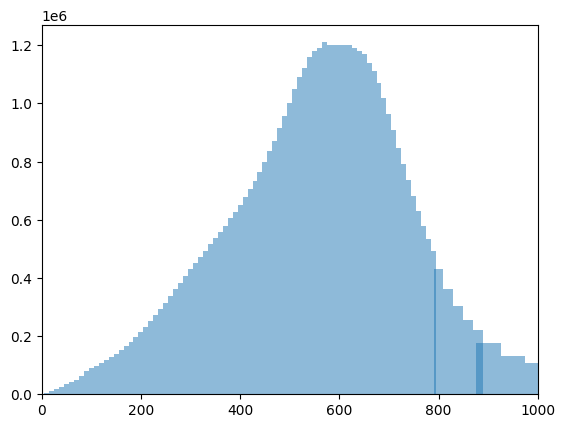

In [15]:
importlib.reload(modules.loaddata)
bins, vals = modules.loaddata.load_t2k("data/t2k/t2kflux_2020_plus250kA_nominal_sk.txt")

plt.bar(bins[:,0], vals, width=bins[:,1]-bins[:,0], alpha=0.5, label="T2K Flux")
plt.xlim(0, 1000)

(0.0, 200.0)

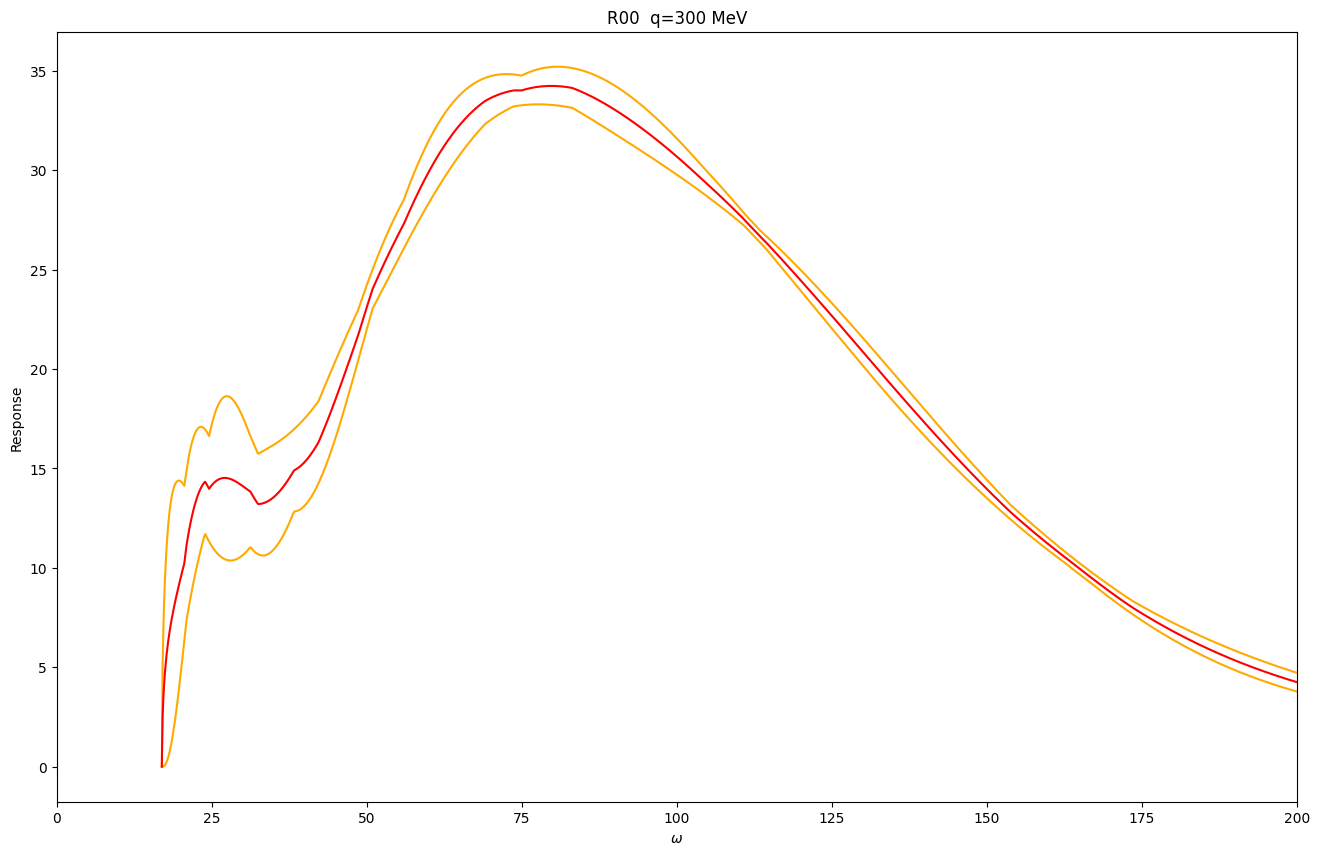

In [31]:
qidx = 5
plt.figure(figsize=(16,10))
for i in [1]:
    plt.plot(data[qidx][i][0], data[qidx][i][2], color="#ffaa00")
    plt.plot(data[qidx][i][0], data[qidx][i][3], color="#ffaa00")
    plt.plot(data[qidx][i][0], data[qidx][i][1], color="red")

plt.xlabel(r"$\omega$")
plt.ylabel("Response")
plt.title(f"{modules.loaddata.ab_initio_curvenames[i]}  q={qvals[qidx]} MeV")
plt.xlim(0,200)